,Name,Price,Rating,Number of Reviews,Product Link
0,"jumper gaming laptop, 12th i5-12450h (up to 4....",999.99,5.0,3.0,https://www.amazon.ca/jumper-i5-12450H-Laptops...
1,"hp 17 inch laptop, fhd display, intel core i5-...",749.98,4.0,21.0,https://www.amazon.ca/HP-Display-i5-1335U-Grap...
3,"hp 14"" fhd ips lightweight laptop, intel n200 ...",399.00,5.0,3.0,https://www.amazon.ca/HP-Lightweight-Processor...
4,lg gram pro 16 inch with wqxga+ (2880 * 1800) ...,2899.97,5.0,2.0,https://www.amazon.ca/LG-Display-Intel%C2%AE-C...
5,"lenovo thinkpad l380 13"" touchscreen laptop, i...",319.00,2.4,2.0,https://www.amazon.ca/Lenovo-ThinkPad-Touchscr...


,Name,Price,Rating,Number of Reviews,Product Link
0,ifixit essential electronics & computer repair...,43.99,4.80,1039.0,https://www.bestbuy.ca/en-ca/product/ifixit-es...
1,ifixit pro tech electronics & computer repair ...,107.99,4.90,1221.0,https://www.bestbuy.ca/en-ca/product/ifixit-pr...
2,ifixit mako 64-bit electronics & computer repa...,59.99,4.92,1242.0,https://www.bestbuy.ca/en-ca/product/ifixit-ma...
3,standard 5ft (1.5m) 10 amps 125 volts black 3 ...,10.00,NaN,NaN,https://www.bestbuy.ca/en-ca/product/standard-...
4,refurbished (excellent) lg electronics 22bk430...,81.89,NaN,NaN,https://www.bestbuy.ca/en-ca/product/refurbish...


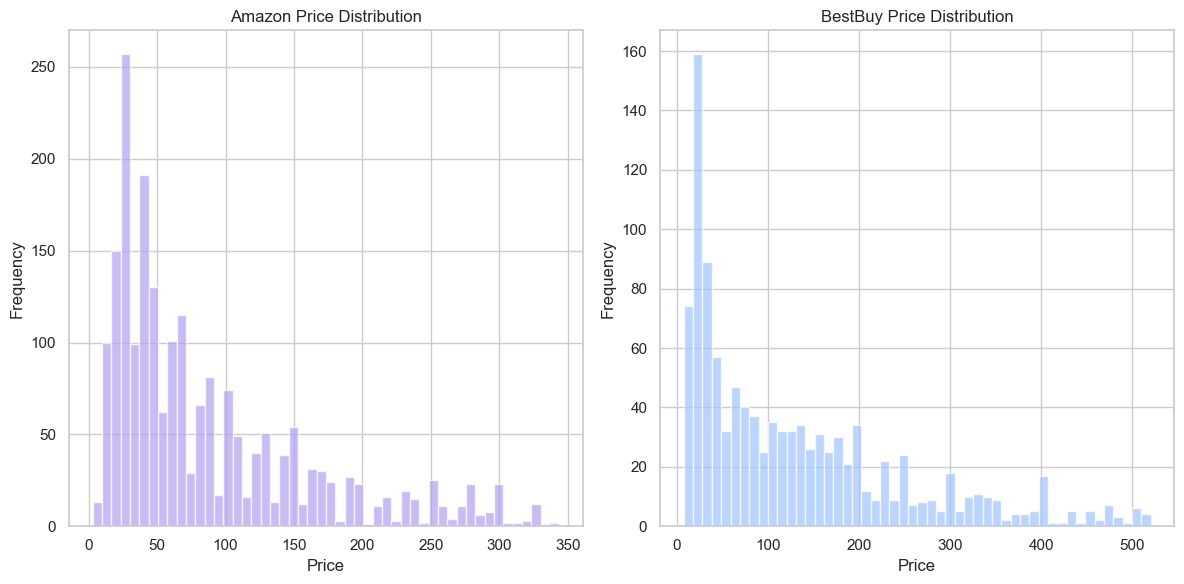

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

amazon_df = pd.read_csv('../csvs/amazon.csv')
bestbuy_df = pd.read_csv('../csvs/bestbuy.csv')

def handle_missing_values(df):
    df['Name'] = df['Name'].replace(["No title available", "N/A"], pd.NA)
    df['Product Link'] = df['Product Link'].replace(["No link available", "N/A"], pd.NA)
    df['Price'] = df['Price'].replace(["Price not available", "N/A", 0], pd.NA)
    df['Rating'] = df['Rating'].replace(["Rating not available", None, 0], pd.NA)
    df['Number of Reviews'] = df['Number of Reviews'].replace(["No reviews available", 0], pd.NA)

    df.dropna(subset=["Name", "Product Link", "Price"], inplace=True)

def clean_numerical_fields(df, fields):
    for field in fields:
        df[field] = df[field].replace(r"[^0-9.-]", "", regex=True)
        df[field] = pd.to_numeric(df[field], errors='coerce')

def convert_to_lowercase(df):
    df['Name'] = df['Name'].str.lower()

handle_missing_values(amazon_df)
handle_missing_values(bestbuy_df)

clean_numerical_fields(amazon_df, ['Price', 'Number of Reviews', 'Rating'])
clean_numerical_fields(bestbuy_df, ['Price', 'Number of Reviews', 'Rating'])

convert_to_lowercase(amazon_df)
convert_to_lowercase(bestbuy_df)

display(amazon_df.head())

display(bestbuy_df.head())

def remove_outliers(df, field):
    Q1 = df[field].quantile(0.25)
    Q3 = df[field].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df.drop(df[(df[field] < lower_bound) | (df[field] > upper_bound)].index, inplace=True)

remove_outliers(amazon_df, 'Price')
remove_outliers(bestbuy_df, 'Price')
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
amazon_df['Price'].dropna().hist(bins=50, color='#b3a0f2', alpha=0.7)
plt.title('Amazon Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
bestbuy_df['Price'].dropna().hist(bins=50, color='#a0c4ff', alpha=0.7)
plt.title('BestBuy Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [57]:
import random
import pandas as pd

merged_df = pd.concat([amazon_df, bestbuy_df], ignore_index=True)

merged_df.drop_duplicates(subset=['Name'], keep='first', inplace=True)
merged_df['Price'] = merged_df['Price'].round(2)
merged_df['Name'] = merged_df['Name'].apply(lambda x: x.replace(",", " "))


sample_size = 200
merged_df = merged_df.sample(n=sample_size, random_state=42)

product_names = merged_df['Name'].tolist()

def generate_frequently_bought_items(current_item, all_items, min_items=10, max_items=80, delimiter=","):
    other_items = [item for item in all_items if item != current_item]
    num_items = random.randint(min_items, max_items)
    frequently_bought = random.sample(other_items, min(num_items, len(other_items)))
    return delimiter.join(frequently_bought)

merged_df['Frequently Bought Items'] = merged_df['Name'].apply(
    lambda x: generate_frequently_bought_items(x, product_names)
)

display(merged_df.head())

,Name,Price,Rating,Number of Reviews,Product Link,Frequently Bought Items
665,gaming keyboard wrist rest pad memory foam key...,9.99,4.7,469.0,https://www.amazon.ca/Gaming-Keyboard-Memory-E...,anyloop smart watch ultra for men women [buil...
1808,suptek adjustable tv wall mount swivel and til...,26.99,4.5,5551.0,https://www.amazon.ca/Adjustable-Bracket-Monit...,monster bluetooth speaker portable bluetooth ...
1455,verbatim wired optical computer mini usb-c mou...,13.59,4.2,1657.0,https://www.amazon.ca/Verbatim-Wired-Optical-C...,rolanstar tv stand deformable tv stand with l...
3142,front rear brake pads wear sensor (4 pack) for...,61.72,NaN,NaN,https://www.bestbuy.ca/en-ca/product/front-rea...,front ceramic rear semi-metallic disc brake pa...
1125,cyber acoustics 4 watt 2.0 computer speaker sy...,24.98,4.0,9191.0,https://www.amazon.ca/Cyber-Acoustics-Computer...,wesecuu light bulb security cameras wireless o...


,Statistic,Value
0,Mean Price,109.241600
1,Median Price,69.990000
2,Variance of Price,10387.639052


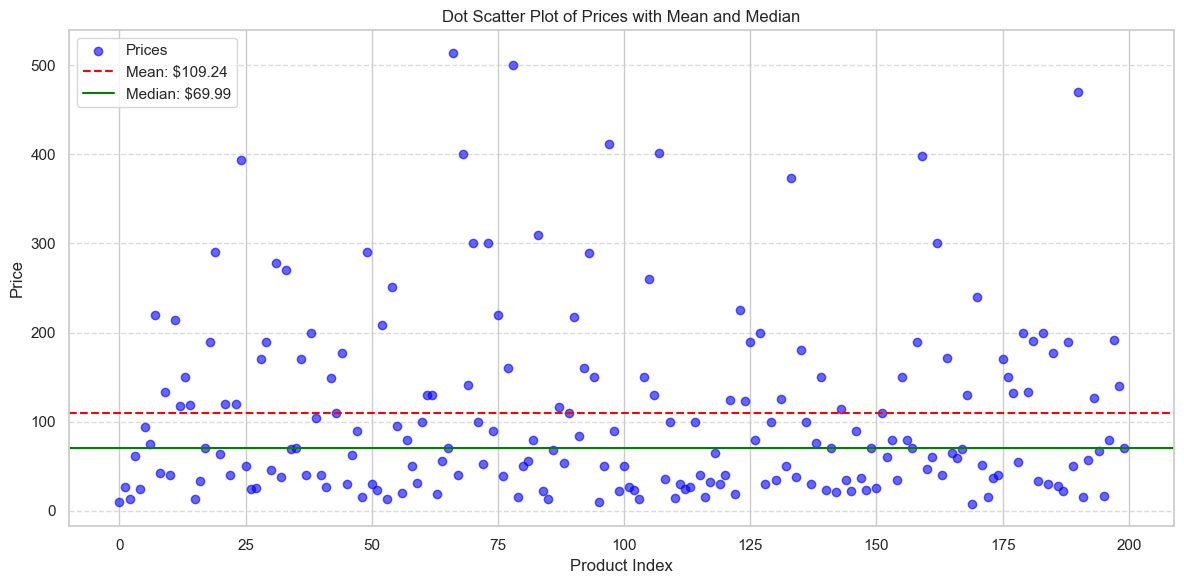

In [58]:
import matplotlib.pyplot as plt

mean_price = merged_df['Price'].mean()
median_price = merged_df['Price'].median()
variance_price = merged_df['Price'].var()

summary_stats = pd.DataFrame({
  'Statistic': ['Mean Price', 'Median Price', 'Variance of Price'],
  'Value': [mean_price, median_price, variance_price]
})

display(summary_stats)

plt.figure(figsize=(12, 6))
plt.scatter(range(len(merged_df)), merged_df['Price'], color='blue', alpha=0.6, label="Prices")

plt.axhline(mean_price, color='red', linestyle='--', linewidth=1.5, label=f"Mean: ${mean_price:.2f}")
plt.axhline(median_price, color='green', linestyle='-', linewidth=1.5, label=f"Median: ${median_price:.2f}")

plt.title("Dot Scatter Plot of Prices with Mean and Median")
plt.xlabel("Product Index")
plt.ylabel("Price")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [63]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder


transactions = merged_df[['Name','Frequently Bought Items']].apply(
    lambda row: [str(row['Name'])]+[str(item) for item in row['Frequently Bought Items'].split(',')], axis=1).tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)

transactions_df = pd.DataFrame(te_ary, columns=te.columns_).astype(int)
display(transactions_df.iloc[:, :5])


,128 in 1 precision screwdriver set repair tool kit with roll-up case professional multi-tool for electronics computer laptop,16 awg gauge speaker wire cable stereo car or home theater cca (100 feet) by install link,2 pcs tool crowbar laptop computer flat head spudger opening pry repair tools electronics,2024 android 14 kids tablet 10 inch tablet for children with family link parental control 8gb+128gb up to 1tb octa-core wifi 6 gms to learn tablets for toddlers shockproof eva case (blue,2024 newest android 14 tablet 10 inch tablet incell screen with 8-core 12gb ram 128gb storage hd display 6000mah 2.4g+5g wifi metal body plimpton p70 (silver)
0,0,0,0,0,1
1,0,0,0,0,1
2,1,0,0,1,0
3,1,0,0,0,1
4,1,1,0,0,0
...,...,...,...,...,...
195,0,0,0,1,0
196,1,0,0,0,1
197,0,0,0,0,0
198,0,0,0,0,0


In [66]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Perform FP-Growth to find frequent itemsets
frequent_itemsets = fpgrowth(transactions_df, min_support=0.05, use_colnames=True)

num_itemsets = len(frequent_itemsets)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0, num_itemsets=num_itemsets)

# Function to recommend products with details
def recommend_with_details(product_name, rules, top_n=5):
    product_name = product_name.strip().lower()
    recommendations = []

    for _, rule in rules.iterrows():
        antecedents = [str(item).lower() for item in rule['antecedents']]
        consequents = [str(item) for item in rule['consequents']]

        if product_name in antecedents:
            for consequent in consequents:
                recommendations.append({
                    'Product': consequent,
                    'Confidence': rule['confidence'],
                    'Lift': rule['lift'],
                    'Support': rule['support']
                })

    recommendations = sorted(recommendations, key=lambda x: x['Confidence'], reverse=True)
    recommendations = [rec for i, rec in enumerate(recommendations) if rec not in recommendations[:i]]
    return recommendations[:top_n]


# Choose a product name from the dataset
product_to_query = augmented_df['Name'].iloc[0]

# Ensure the product exists in transactions
product_exists = any(
    product_to_query.lower() in [item.lower() for item in transaction] for transaction in transactions
)

print(f"Product to query: {product_to_query}")

if product_exists:
    recommended_products = recommend_with_details(product_to_query, rules, top_n=5)
    if recommended_products:
        recommendations_df = pd.DataFrame(recommended_products)
        print(f"Recommendations for '{product_to_query}':\n")
        display(recommendations_df)
    else:
        print(f"No recommendations found for '{product_to_query}' based on FP-Growth.")
else:
    print(f"'{product_to_query}' does not exist in the transaction dataset.")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Product to query: gaming keyboard wrist rest pad memory foam keyboard palm rest  ergonomic hand rest wrist rest for computer keyboard laptop mac (sky blue)
Recommendations for 'gaming keyboard wrist rest pad memory foam keyboard palm rest  ergonomic hand rest wrist rest for computer keyboard laptop mac (sky blue)':



,Product,Confidence,Lift,Support
0,jbl vibe beam - true wireless earbuds - black,0.909091,3.430532,0.050
1,jbl vibe beam - true wireless earbuds - black,0.846154,3.193033,0.055
2,amazon echo pop | full sound compact smart spe...,0.846154,2.820513,0.055
3,nulea m501 wireless trackball mouse rechargea...,0.846154,3.193033,0.055
4,amazon echo pop | full sound compact smart spe...,0.833333,2.777778,0.050


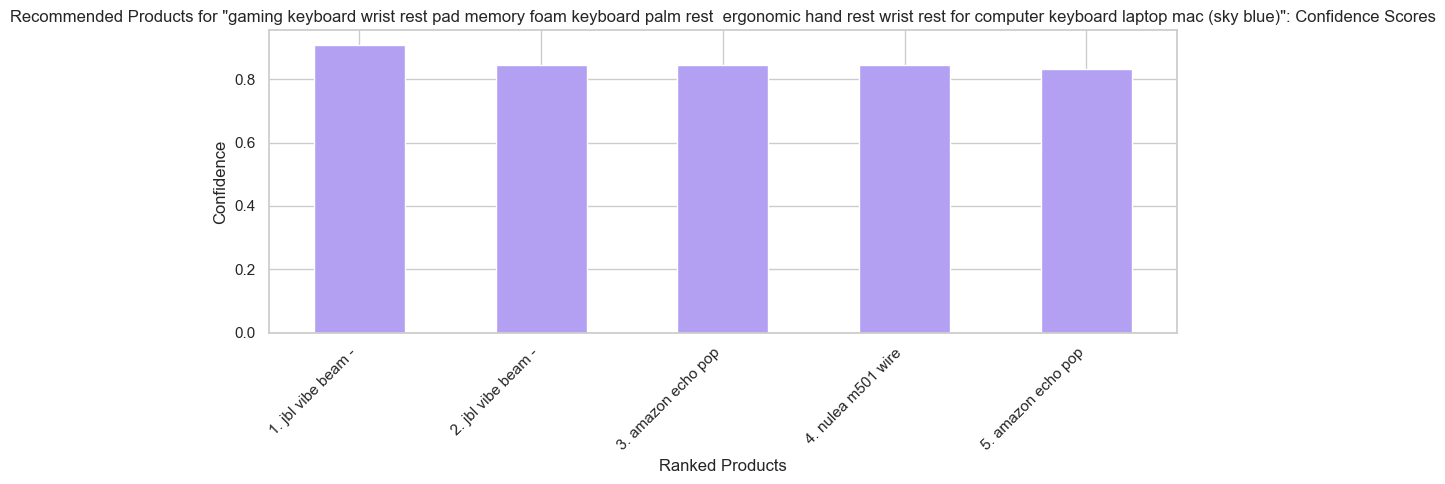

In [67]:
import seaborn as sns

def plot_recommendations_confidence(recommendations_df, query_product):
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))

    recommendations_df = recommendations_df.head(5)

    recommendations_df.set_index('Product', inplace=True)
    ax = recommendations_df['Confidence'].plot(kind='bar', figsize=(10, 5), color='#b3a0f2')

    plt.xlabel('Ranked Products')
    plt.ylabel('Confidence')
    plt.title(f'Recommended Products for "{query_product}": Confidence Scores')

    ax.set_xticks(range(len(recommendations_df)))
    ax.set_xticklabels([str(i+1) + ". " + recommendations_df.index[i][:15] for i in range(len(recommendations_df))], rotation=45, ha='right')

    plt.tight_layout()

    plt.show()

recommended_products = recommend_with_details(product_to_query, rules, top_n=5)
recommendations_df = pd.DataFrame(recommended_products)

plot_recommendations_confidence(recommendations_df, product_to_query)

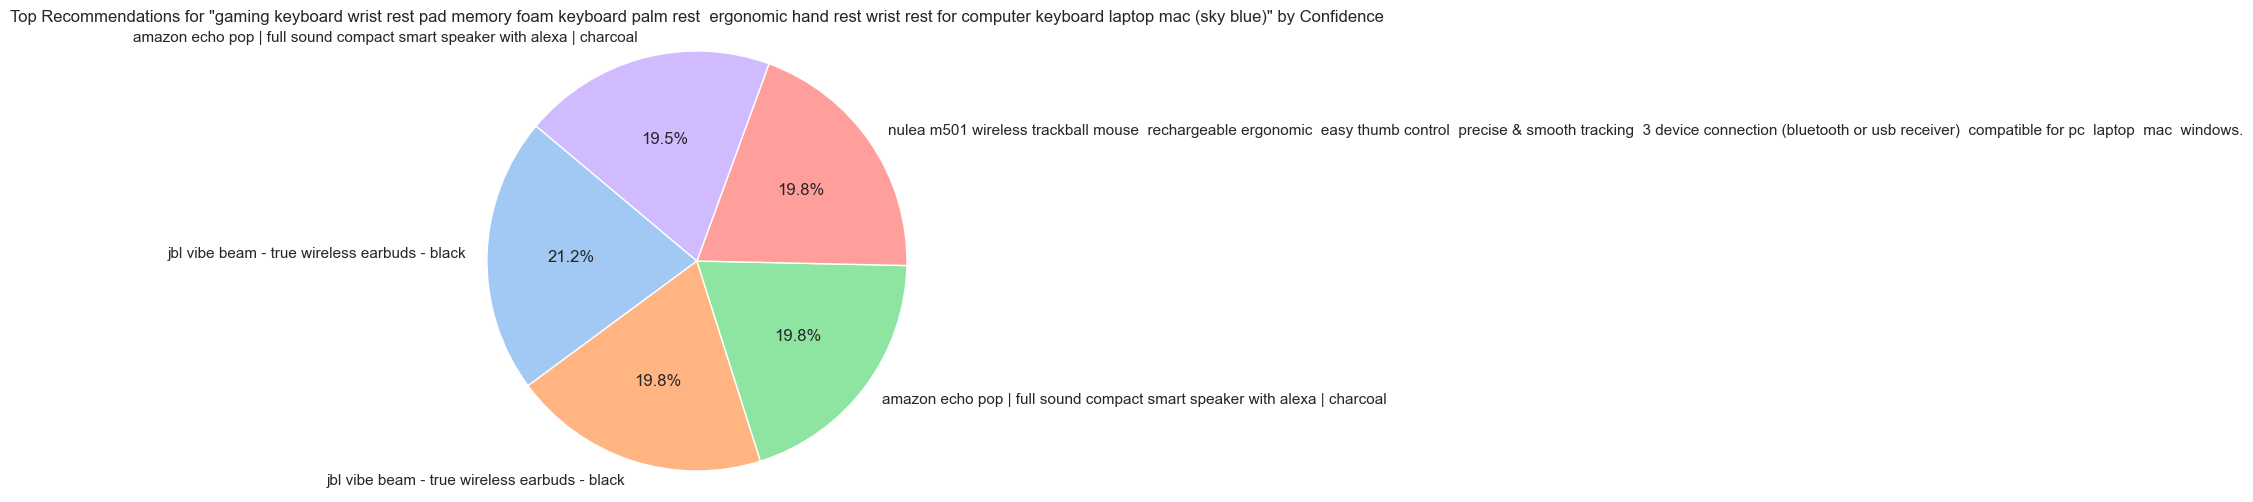

In [68]:
recommended_products = recommend_with_details(product_to_query, rules, top_n=5)
recommendations_df = pd.DataFrame(recommended_products)

plt.figure(figsize=(10, 6))
plt.pie(recommendations_df['Confidence'], labels=recommendations_df['Product'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title(f'Top Recommendations for "{product_to_query}" by Confidence')
plt.axis('equal') 
plt.show()